# **Day 94: Project 3 - Flood Mapping from Sentinel-1 SAR: Thresholds, Change Detection, Random Forest and U-Net**
*Module 13 - Remote Sensing ML and Publication Projects*

Floods happen under clouds, so flood mapping relies on **SAR**. Calm water is a mirror for radar: the signal is reflected away, and water looks dark. That is easy until reality intervenes:

| Condition | SAR appearance | Problem |
|---|---|---|
| Open calm flood water | very dark (VV ~ -20 dB) | easy |
| **Wind-roughened** water | brighter (Bragg scattering) | missed by thresholds |
| **Flooded vegetation** | *brighter* (double bounce between water and trunks) | missed by "dark = water" |
| **Flooded urban** areas | brighter (double bounce off walls) | missed |
| **Radar shadow** on steep slopes | dark, like water | false alarms |
| Permanent water | dark before **and** after | must be excluded |

> **Working title**: *Flood mapping in the Damodar basin from Sentinel-1: are deep networks worth it compared with change detection?*

We compare four methods of increasing complexity on **independent test events** and, most importantly, analyse **where each one fails**.

> Radar sees through clouds and calm water looks dark, which makes Sentinel-1 ideal for flood mapping. We compare simple thresholds, change detection, random forest and a U-Net, and study where each one fails.
>
> *Example:* Flooded paddy fields look dark and are easy to detect, but flooded forest looks brighter (double bounce) and fools simple thresholds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, copy, json
from pathlib import Path
from scipy.ndimage import uniform_filter
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
import rs_utils as ru
ru.pub_style(); torch.set_num_threads(4)
PROJ = Path("project3_flood"); PROJ.mkdir(exist_ok=True)
COND = ["no flood", "open water", "wind-roughened", "flooded vegetation", "flooded urban", "radar shadow"]

## **1. The Data: Flood Events**
Each simulated event is a 256 x 256 pixel (5 x 5 km) scene with a pre-event and a post-event Sentinel-1 VV/VH image, a DEM and the **HAND** layer (Height Above Nearest Drainage, Nobre et al. 2011). Low-HAND land floods first. We use **events 0-7 for training, 8-9 for validation and 100-102 for testing**. The test events are never seen during development, as in a real "train on past floods, map the next one" setting. Open benchmark datasets of this kind exist for real data (e.g. Sen1Floods11, Bonafilia et al. 2020).

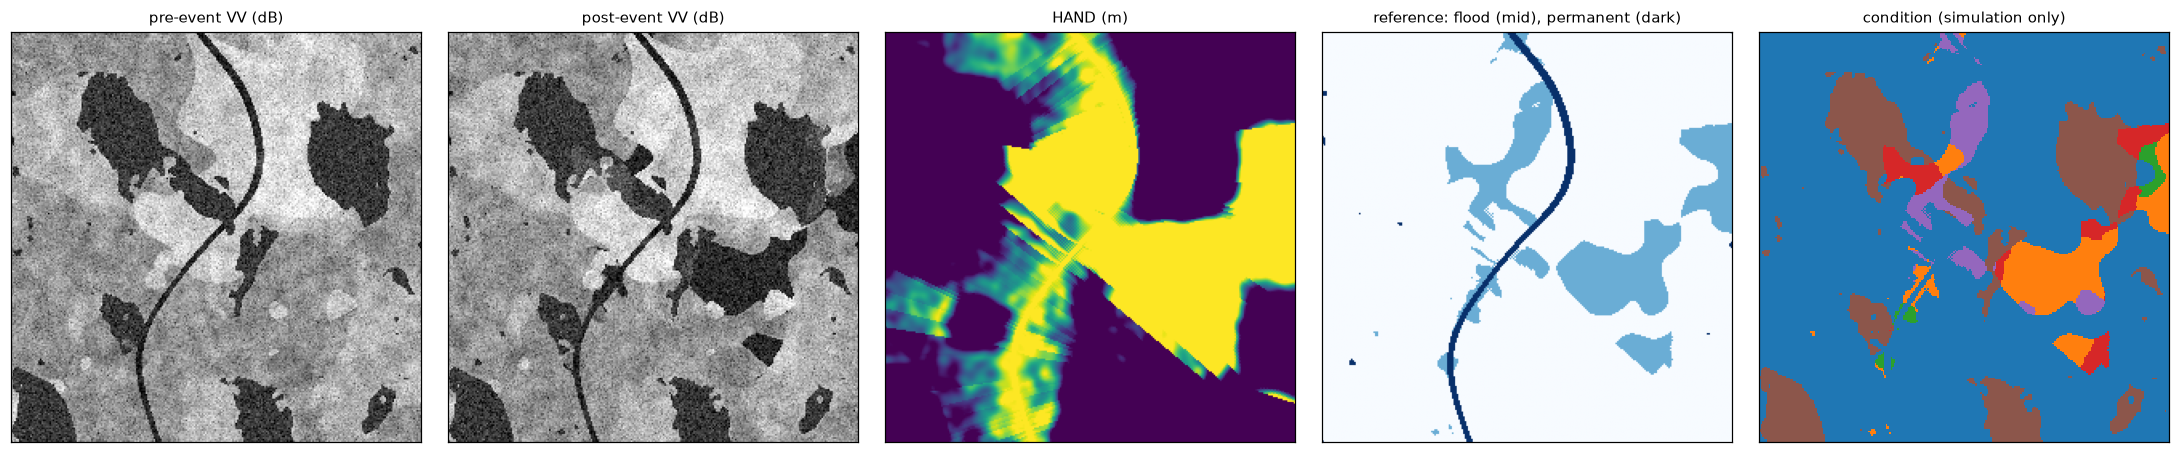

no flood              48398
open water             3637
wind-roughened          413
flooded vegetation     1640
flooded urban          2039
radar shadow           9409
dtype: int64


In [2]:
events = {s: ru.make_flood_scene(256, seed=s) for s in list(range(10)) + [100, 101, 102]}
train_ids, val_ids, test_ids = list(range(8)), [8, 9], [100, 101, 102]
ev = events[100]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(ev["pre"][0], cmap="gray", vmin=-25, vmax=0); axes[0].set_title("pre-event VV (dB)")
axes[1].imshow(ev["post"][0], cmap="gray", vmin=-25, vmax=0); axes[1].set_title("post-event VV (dB)")
axes[2].imshow(ev["hand"], cmap="viridis_r", vmax=40); axes[2].set_title("HAND (m)")
axes[3].imshow(np.where(ev["permanent_water"], 2, ev["flood"]), cmap="Blues", vmin=0, vmax=2); axes[3].set_title("reference: flood (mid), permanent (dark)")
im = axes[4].imshow(ev["condition"], cmap="tab10", vmin=0, vmax=9, interpolation="nearest"); axes[4].set_title("condition (simulation only)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print(pd.Series(np.bincount(ev["condition"].ravel(), minlength=6), index=COND))

## **2. Speckle and the Lee Filter**
SAR intensity is multiplied by **speckle**, random noise from coherent interference, with a coefficient of variation of 1/sqrt(L) for L looks. The **Lee filter** (Lee 1980) averages in homogeneous areas and preserves edges where the local variance exceeds what speckle alone explains:

z = mean + w (I - mean), with w = max(0, (var - mean^2/L) / var).

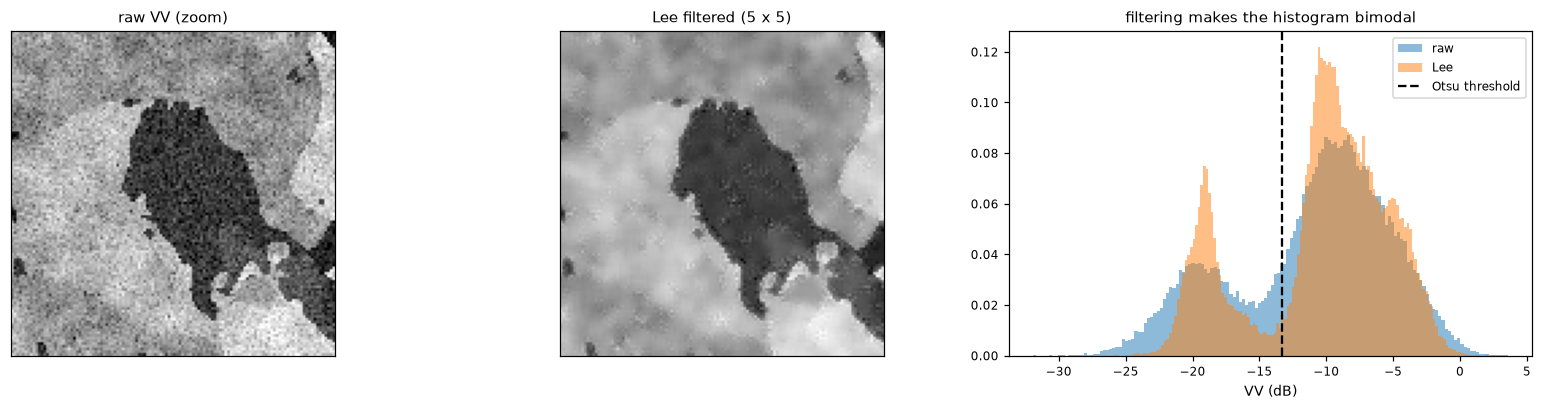

In [3]:
def lee_filter(db, size=5, looks=4.4):
    lin = 10 ** (db / 10); m = uniform_filter(lin, size); v = uniform_filter(lin ** 2, size) - m ** 2
    w = np.clip((v - m ** 2 / looks) / np.maximum(v, 1e-12), 0, 1)
    return (10 * np.log10(np.maximum(m + w * (lin - m), 1e-6))).astype(np.float32)

def otsu(values, bins=256):
    h, edges = np.histogram(values[np.isfinite(values)], bins); c = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(h); w1 = w0[-1] - w0; m0 = np.cumsum(h * c) / np.maximum(w0, 1); m1 = (np.sum(h * c) - np.cumsum(h * c)) / np.maximum(w1, 1)
    return c[np.argmax(w0 * w1 * (m0 - m1) ** 2)]

for e in events.values():
    e["pre_f"] = np.stack([lee_filter(b) for b in e["pre"]]); e["post_f"] = np.stack([lee_filter(b) for b in e["post"]])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].imshow(ev["post"][0][:120, :120], cmap="gray", vmin=-25, vmax=0); axes[0].set_title("raw VV (zoom)")
axes[1].imshow(ev["post_f"][0][:120, :120], cmap="gray", vmin=-25, vmax=0); axes[1].set_title("Lee filtered (5 x 5)")
axes[2].hist(ev["post"][0].ravel(), 150, alpha=0.5, density=True, label="raw"); axes[2].hist(ev["post_f"][0].ravel(), 150, alpha=0.5, density=True, label="Lee")
axes[2].axvline(otsu(ev["post_f"][0]), c="k", ls="--", label="Otsu threshold"); axes[2].legend(); axes[2].set_xlabel("VV (dB)"); axes[2].set_title("filtering makes the histogram bimodal")
for ax in axes[:2]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## **3. Method 1 and 2: Otsu Threshold and Change Detection**
- **M1, single-image Otsu**: water = post VV < Otsu threshold. Flood = water minus pre-event water (also from Otsu).
- **M2, change detection**: flood = (post VV - pre VV < -3 dB) **and** post VV is water-like, then masked to plausible terrain (HAND < 15 m, slope < 8 deg). This is close to the UN-SPIDER recommended practice, and it removes permanent water and shadow automatically, because they are dark on both dates.

In [4]:
def m1_otsu(e):
    t = otsu(e["post_f"][0]); return (e["post_f"][0] < t) & ~(e["pre_f"][0] < otsu(e["pre_f"][0]))

def m2_change(e, drop_db=-3.0, hand_max=15, slope_max=8):
    diff = e["post_f"][0] - e["pre_f"][0]
    return (diff < drop_db) & (e["post_f"][0] < -14) & (e["hand"] < hand_max) & (e["slope"] < slope_max)

def scores(pred, ref):
    tp = np.sum(pred & ref); fp = np.sum(pred & ~ref); fn = np.sum(~pred & ref)
    return {"IoU": tp / (tp + fp + fn), "F1": 2 * tp / (2 * tp + fp + fn), "precision": tp / max(tp + fp, 1), "recall": tp / max(tp + fn, 1)}

def evaluate(method, ids=test_ids):
    preds = {i: method(events[i]) for i in ids}
    P = np.concatenate([preds[i].ravel() for i in ids]); R = np.concatenate([events[i]["flood"].ravel() for i in ids])
    return scores(P, R), preds

results, predictions = {}, {}
for name, fn in [("M1 Otsu (post VV)", m1_otsu), ("M2 change detection + HAND", m2_change)]:
    results[name], predictions[name] = evaluate(fn)
pd.DataFrame(results).T.round(3)

,IoU,F1,precision,recall
M1 Otsu (post VV),0.536,0.698,0.926,0.560
M2 change detection + HAND,0.407,0.579,0.967,0.413


## **4. Method 3: Random Forest on Pixel Features**
A supervised pixel classifier can combine many cues: both dates, both polarisations, their differences and ratios, local texture, and terrain. Training pixels come from the training events only.

In [5]:
def pixel_features(e):
    pre, post = e["pre_f"], e["post_f"]
    f = [pre[0], pre[1], post[0], post[1], post[0] - pre[0], post[1] - pre[1], post[0] - post[1],
         uniform_filter(post[0], 9), np.sqrt(np.clip(uniform_filter(post[0] ** 2, 9) - uniform_filter(post[0], 9) ** 2, 0, None)),
         uniform_filter(post[0] - pre[0], 9), np.log1p(e["hand"]), e["slope"]]
    return np.stack(f, -1).reshape(-1, len(f))
FEAT = ["preVV", "preVH", "postVV", "postVH", "dVV", "dVH", "postVV-VH", "VV mean9", "VV sd9", "dVV mean9", "log HAND", "slope"]
rng = np.random.default_rng(0)
Xs, ys = [], []
for i in train_ids:
    Xi = pixel_features(events[i]); yi = events[i]["flood"].ravel(); pick = rng.choice(len(yi), 6000, replace=False)
    Xs.append(Xi[pick]); ys.append(yi[pick])
rf = RandomForestClassifier(300, min_samples_leaf=3, n_jobs=-1, random_state=0).fit(np.vstack(Xs), np.concatenate(ys))
m3 = lambda e: rf.predict(pixel_features(e)).reshape(e["flood"].shape).astype(bool)
results["M3 random forest"], predictions["M3 random forest"] = evaluate(m3)
pd.Series(rf.feature_importances_, index=FEAT).sort_values(ascending=False).round(3).head(8)

log HAND     0.229
dVV mean9    0.165
dVH          0.155
dVV          0.125
postVV       0.088
postVH       0.054
VV mean9     0.048
VV sd9       0.032
dtype: float64

## **5. Method 4: U-Net**
The U-Net (Ronneberger et al. 2015; Day 64) learns spatial context: the shape of flooded areas, their connection to the river, and the texture of flooded vegetation. Inputs: 6 channels (pre and post VV/VH, log HAND, slope), standardised with training statistics. Training uses random 128 x 128 crops.

**Augmentation must respect SAR geometry.** Radar looks sideways (east or west for Sentinel-1's near-polar orbit), so shadows fall on one side of a hill. A left-right flip or a 90-degree rotation creates shadows that cannot occur. We flip only **up-down** (along the orbit track).

In [6]:
def stack_inputs(e):
    return np.concatenate([e["pre_f"], e["post_f"], np.log1p(e["hand"])[None], e["slope"][None]]).astype(np.float32)
inputs = {i: stack_inputs(e) for i, e in events.items()}
mu = np.mean([inputs[i].mean((1, 2)) for i in train_ids], 0); sd = np.mean([inputs[i].std((1, 2)) for i in train_ids], 0)
norm = {i: ((x - mu[:, None, None]) / sd[:, None, None]).astype(np.float32) for i, x in inputs.items()}

def block(ci, co):
    return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                         nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, c_in, base=16, p_drop=0.1):
        super().__init__(); c = [base, 2 * base, 4 * base, 8 * base]
        self.e1, self.e2, self.e3, self.b = block(c_in, c[0]), block(c[0], c[1]), block(c[1], c[2]), block(c[2], c[3])
        self.u3, self.u2, self.u1 = nn.ConvTranspose2d(c[3], c[2], 2, 2), nn.ConvTranspose2d(c[2], c[1], 2, 2), nn.ConvTranspose2d(c[1], c[0], 2, 2)
        self.d3, self.d2, self.d1 = block(c[3], c[2]), block(c[2], c[1]), block(c[1], c[0])
        self.pool, self.drop, self.out = nn.MaxPool2d(2), nn.Dropout2d(p_drop), nn.Conv2d(c[0], 1, 1)
    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.pool(e1)); e3 = self.e3(self.pool(e2)); b = self.drop(self.b(self.pool(e3)))
        d3 = self.d3(torch.cat([self.u3(b), e3], 1)); d2 = self.d2(torch.cat([self.u2(d3), e2], 1)); d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

def batch(ids, n=16, size=128):
    xs, ys_ = [], []
    for _ in range(n):
        i = ids[rng.integers(len(ids))]; r, c = rng.integers(0, 256 - size + 1, 2)
        x = norm[i][:, r:r + size, c:c + size]; t = events[i]["flood"][r:r + size, c:c + size]
        if rng.random() < 0.5: x, t = x[:, ::-1], t[::-1]                         # along-track flip only
        xs.append(x.copy()); ys_.append(t.copy())
    return torch.as_tensor(np.stack(xs)), torch.as_tensor(np.stack(ys_)[:, None].astype(np.float32))

def dice_bce(logits, target):
    p = torch.sigmoid(logits); inter = (p * target).sum(); dice = 1 - (2 * inter + 1) / (p.sum() + target.sum() + 1)
    return F.binary_cross_entropy_with_logits(logits, target) + dice

@torch.no_grad()
def predict_prob(model, i):
    model.eval(); return torch.sigmoid(model(torch.as_tensor(norm[i][None])))[0, 0].numpy()

def train_unet(channels, epochs=18, steps=30, seed=0):
    torch.manual_seed(seed)
    model = UNet(len(channels)); opt = torch.optim.AdamW(model.parameters(), 2e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, 3e-3, total_steps=epochs * steps)
    best, state, hist = -1, None, []
    for ep in range(epochs):
        model.train()
        for _ in range(steps):
            xb, yb = batch(train_ids); loss = dice_bce(model(xb[:, channels]), yb)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        model.eval()
        with torch.no_grad():
            P = np.concatenate([(torch.sigmoid(model(torch.as_tensor(norm[i][None][:, channels])))[0, 0].numpy() > 0.5).ravel() for i in val_ids])
        iou = scores(P, np.concatenate([events[i]["flood"].ravel() for i in val_ids]))["IoU"]; hist.append((loss.item(), iou))
        if iou > best: best, state = iou, copy.deepcopy(model.state_dict())
    model.load_state_dict(state); model.channels = channels; model.hist = hist
    return model

t0 = time.perf_counter()
unet = train_unet(list(range(6)))
print(f"U-Net: {sum(p.numel() for p in unet.parameters()):,} parameters, trained in {time.perf_counter() - t0:.0f} s, best validation IoU {max(h[1] for h in unet.hist):.3f}")

@torch.no_grad()
def m4_unet(e, model=None):
    model = model or unet; i = [k for k, v in events.items() if v is e][0]; model.eval()
    return (torch.sigmoid(model(torch.as_tensor(norm[i][None][:, model.channels])))[0, 0].numpy() > 0.5)
results["M4 U-Net"], predictions["M4 U-Net"] = evaluate(m4_unet)
table1 = pd.DataFrame(results).T
table1.round(3).to_csv(PROJ / "table1_methods.csv"); table1.round(3)

U-Net: 483,873 parameters, trained in 175 s, best validation IoU 0.881


,IoU,F1,precision,recall
M1 Otsu (post VV),0.536,0.698,0.926,0.560
M2 change detection + HAND,0.407,0.579,0.967,0.413
M3 random forest,0.826,0.905,0.889,0.921
M4 U-Net,0.844,0.915,0.894,0.938


## **6. Error Analysis by Condition (Table 2)**
A single IoU hides **why** methods differ. Measure recall for each flood condition, and the false-alarm rate in radar shadow and on dry land. In real studies, we obtain these strata from land cover (flooded vegetation, urban), wind data, and a layover/shadow mask computed from the DEM and the orbit geometry.

In [7]:
rows = {}
cond_all = np.concatenate([events[i]["condition"].ravel() for i in test_ids])
flood_all = np.concatenate([events[i]["flood"].ravel() for i in test_ids])
for name, preds in predictions.items():
    P = np.concatenate([preds[i].ravel() for i in test_ids]); r = {}
    for k in [1, 2, 3, 4]: r[f"recall: {COND[k]}"] = P[cond_all == k].mean()
    r["false alarms: radar shadow"] = P[cond_all == 5].mean()
    r["false alarms: other dry land"] = P[(~flood_all) & (cond_all == 0)].mean()
    rows[name] = r
table2 = pd.DataFrame(rows).T
table2.round(3).to_csv(PROJ / "table2_error_by_condition.csv"); table2.round(3)

,recall: open water,recall: wind-roughened,recall: flooded vegetation,recall: flooded urban,false alarms: radar shadow,false alarms: other dry land
M1 Otsu (post VV),0.971,0.585,0.001,0.001,0.007,0.007
M2 change detection + HAND,0.761,0.132,0.000,0.000,0.000,0.003
M3 random forest,0.991,0.901,0.816,0.850,0.011,0.020
M4 U-Net,0.995,0.953,0.858,0.860,0.017,0.018


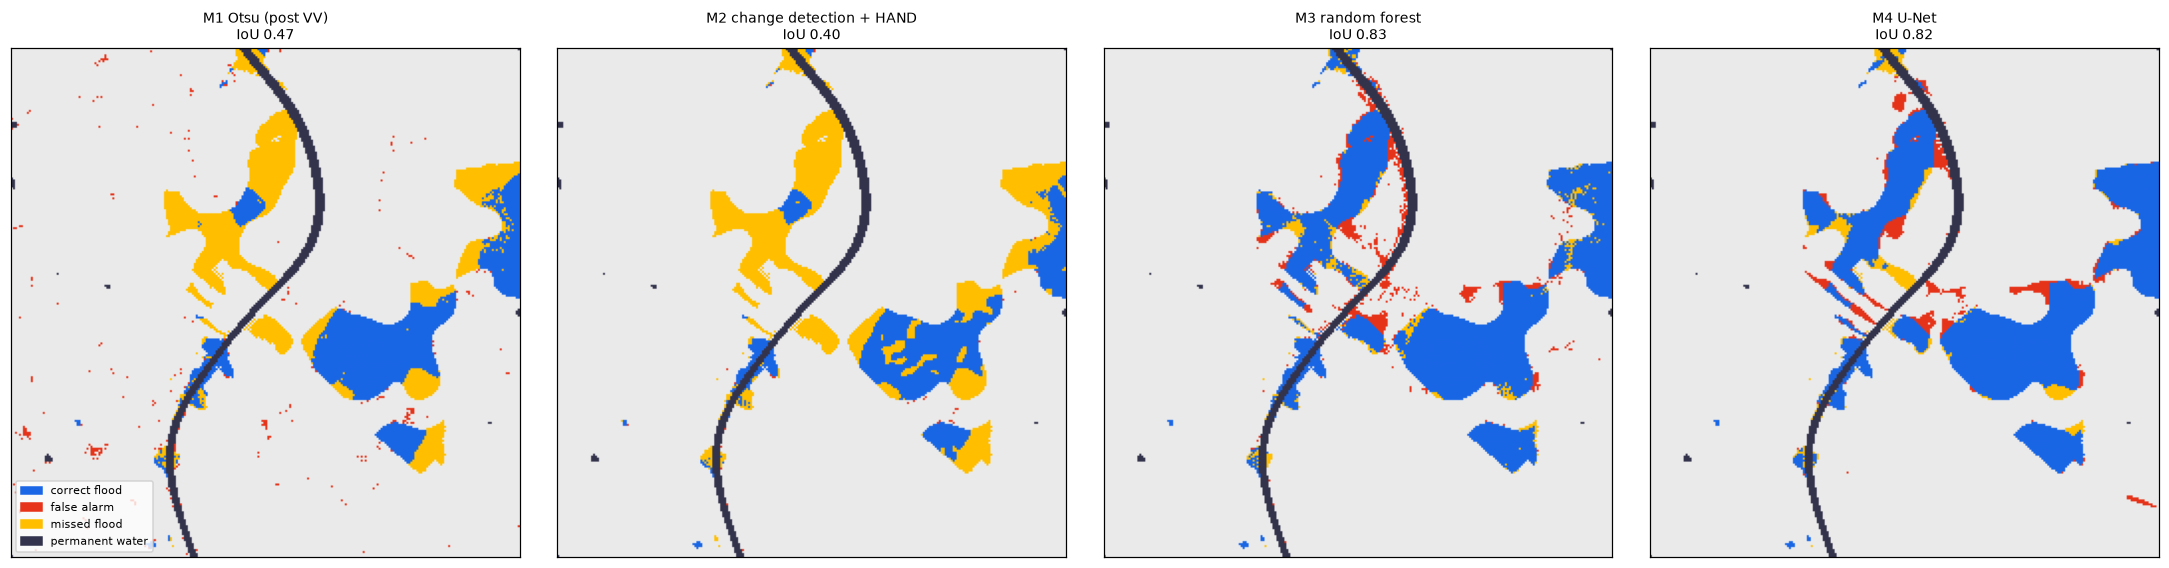

In [8]:
i = test_ids[0]; ref = events[i]["flood"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, predictions):
    p = predictions[name][i]
    rgb = np.ones(ref.shape + (3,)) * 0.92
    rgb[p & ref] = [0.1, 0.4, 0.9]; rgb[p & ~ref] = [0.9, 0.2, 0.1]; rgb[~p & ref] = [1.0, 0.75, 0.0]; rgb[events[i]["permanent_water"]] = [0.2, 0.2, 0.3]
    ax.imshow(rgb); ax.set_title(f"{name}\nIoU {scores(p, ref)['IoU']:.2f}", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in [[0.1, 0.4, 0.9], [0.9, 0.2, 0.1], [1.0, 0.75, 0.0], [0.2, 0.2, 0.3]]],
               labels=["correct flood", "false alarm", "missed flood", "permanent water"], loc="lower left", fontsize=7)
plt.tight_layout(); fig.savefig(PROJ / "fig_flood_methods.png", dpi=300, bbox_inches="tight"); plt.show()

What Tables 1-2 show:
- **Otsu on the post-event image** finds open water. Because pre-event water is subtracted, it also avoids most radar shadow (dark on both dates). It misses every flood type that becomes *brighter*.
- **Change detection with HAND and slope masks** is the most precise method (fewest false alarms), but its fixed thresholds cost recall even on open water, and it is blind to wind-roughened water, flooded vegetation and flooded urban areas. Tuning the thresholds helps (Practice Problem 1); the blind spots remain.
- **The supervised models** learn that a brightness *increase* in a low-HAND area also means flood, so they recover most flooded vegetation and urban pixels. The U-Net adds spatial context and is best on these double-bounce classes. The price is slightly more false alarms on dry land.
- **Wind-roughened water** defeats the thresholds but is learned by the supervised models here. In real events, strong wind can make water as bright as dry land, which remains a known failure mode that needs multi-temporal or optical support.

## **7. Flood Exposure**
Decision makers need impact numbers: flooded cropland, flooded built-up area. Intersect the flood map with a land-cover map (Project 1) and report both mapped and reference values.

In [9]:
PIX_HA = 0.04
rows = []
for name in ["M2 change detection + HAND", "M4 U-Net"]:
    for k, cl in enumerate(ru.LC_CLASSES[1:], start=1):
        mapped = sum(np.sum(predictions[name][i] & (events[i]["lc"] == k)) for i in test_ids) * PIX_HA
        rows.append({"method": name, "land cover": cl, "flooded area (ha)": mapped})
ref_rows = [{"method": "reference", "land cover": cl, "flooded area (ha)": sum(np.sum(events[i]["flood"] & (events[i]["lc"] == k)) for i in test_ids) * PIX_HA}
            for k, cl in enumerate(ru.LC_CLASSES[1:], start=1)]
exposure = pd.DataFrame(rows + ref_rows).pivot(index="land cover", columns="method", values="flooded area (ha)")
exposure.round(1)

method,M2 change detection + HAND,M4 U-Net,reference
land cover,,,
built_up,0.0,235.2,197.2
cropland,152.6,166.2,166.1
forest,0.0,246.3,233.0
mining_bare,17.4,23.2,23.7
shrub_grass,289.0,479.0,477.5


# **Part 2: Going Deeper**

## **8. Ablation: Does the U-Net Need Terrain?**
HAND is powerful prior knowledge: water collects in low places. However, flash floods, ponding from rain and dam breaks can happen at higher HAND. A model that leans too heavily on HAND will miss them. Train a SAR-only U-Net and compare.

In [10]:
unet_sar = train_unet([0, 1, 2, 3])
results["M4b U-Net (SAR only)"], predictions["M4b U-Net (SAR only)"] = evaluate(lambda e: m4_unet(e, unet_sar))
pd.DataFrame(results).T.round(3)

,IoU,F1,precision,recall
M1 Otsu (post VV),0.536,0.698,0.926,0.560
M2 change detection + HAND,0.407,0.579,0.967,0.413
M3 random forest,0.826,0.905,0.889,0.921
M4 U-Net,0.844,0.915,0.894,0.938
M4b U-Net (SAR only),0.821,0.901,0.912,0.891


## **9. Running This on Real Data (GEE)**
```python
s1 = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi)
      .filter(ee.Filter.eq("instrumentMode", "IW")).filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
      .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING")))                       # same orbit pass before and after!
pre = s1.filterDate("2024-07-01", "2024-07-20").median().clip(aoi)
post = s1.filterDate("2024-08-10", "2024-08-16").mosaic().clip(aoi)
smooth = lambda img: img.focal_median(50, "circle", "meters")
diff = smooth(post).select("VV").subtract(smooth(pre).select("VV"))
hand = ee.Image("MERIT/Hydro/v1_0_1").select("hnd")
flood = diff.lt(-3).And(smooth(post).select("VV").lt(-14)).And(hand.lt(15)) \
            .updateMask(ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("seasonality").lt(10).unmask(1))   # remove permanent water
```
Key rules: compare images from the **same orbit pass and relative orbit**, report the image dates, and validate with optical images (if cloud-free) or field and drone data.

## **Practice Problems**
1. Vary the change-detection threshold from -1 to -6 dB and plot IoU. How sensitive is M2 to this choice?
2. Remove the Lee filter (use raw dB) for M1 and M2. How much does speckle filtering matter?
3. Compute the U-Net's IoU separately for each test event. How much does it vary, and why should a paper report per-event scores?
4. *(Advanced)* Use **MC dropout** (Day 77): keep `Dropout2d` active at test time, predict 20 times, and map the pixel-wise standard deviation. Where is the U-Net uncertain?

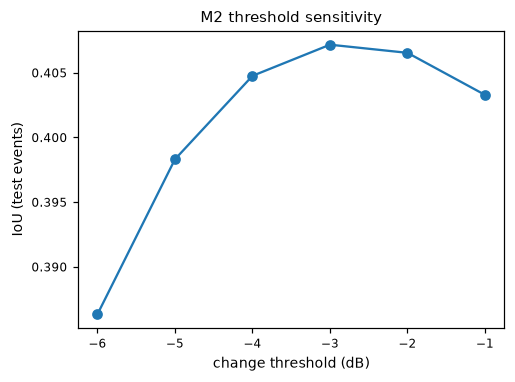

In [11]:
# Solution 1
ths = [-1, -2, -3, -4, -5, -6]
ious = [evaluate(lambda e, t=t: m2_change(e, drop_db=t))[0]["IoU"] for t in ths]
plt.figure(figsize=(5, 3.5)); plt.plot(ths, ious, "-o"); plt.xlabel("change threshold (dB)"); plt.ylabel("IoU (test events)"); plt.title("M2 threshold sensitivity"); plt.show()

In [12]:
# Solution 2
def m1_raw(e):
    return (e["post"][0] < otsu(e["post"][0])) & ~(e["pre"][0] < otsu(e["pre"][0]))
def m2_raw(e):
    return ((e["post"][0] - e["pre"][0]) < -3) & (e["post"][0] < -14) & (e["hand"] < 15) & (e["slope"] < 8)
print(f"M1 IoU raw {evaluate(m1_raw)[0]['IoU']:.3f} vs Lee {results['M1 Otsu (post VV)']['IoU']:.3f} | "
      f"M2 IoU raw {evaluate(m2_raw)[0]['IoU']:.3f} vs Lee {results['M2 change detection + HAND']['IoU']:.3f}")

M1 IoU raw 0.356 vs Lee 0.536 | M2 IoU raw 0.390 vs Lee 0.407


In [13]:
# Solution 3
for i in test_ids:
    print(f"event {i}: flood share {events[i]['flood'].mean():.1%}, U-Net IoU {scores(predictions['M4 U-Net'][i], events[i]['flood'])['IoU']:.3f}, "
          f"change detection IoU {scores(predictions['M2 change detection + HAND'][i], events[i]['flood'])['IoU']:.3f}")

event 100: flood share 11.8%, U-Net IoU 0.820, change detection IoU 0.399
event 101: flood share 19.1%, U-Net IoU 0.886, change detection IoU 0.385
event 102: flood share 10.9%, U-Net IoU 0.800, change detection IoU 0.455


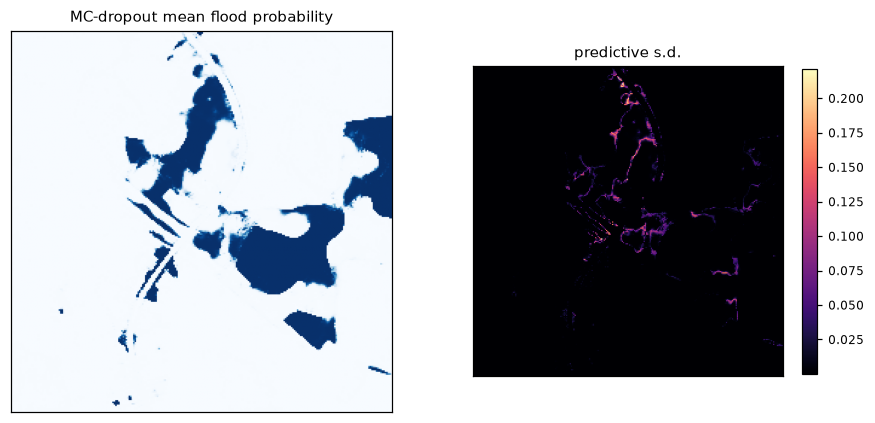

mean s.d. on errors 0.027 vs on correct pixels 0.001


In [14]:
# Solution 4
i = test_ids[0]; unet.eval()
for m in unet.modules():
    if isinstance(m, nn.Dropout2d): m.train()
with torch.no_grad():
    samples = np.stack([torch.sigmoid(unet(torch.as_tensor(norm[i][None])))[0, 0].numpy() for _ in range(20)])
unet.eval()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(samples.mean(0), cmap="Blues"); axes[0].set_title("MC-dropout mean flood probability")
im = axes[1].imshow(samples.std(0), cmap="magma"); fig.colorbar(im, ax=axes[1], shrink=0.8); axes[1].set_title("predictive s.d.")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.show()
err = (samples.mean(0) > 0.5) != events[i]["flood"]
print(f"mean s.d. on errors {samples.std(0)[err].mean():.3f} vs on correct pixels {samples.std(0)[~err].mean():.3f}")

## **Key References**
- Twele, A., Cao, W., Plank, S., & Martinis, S. (2016). Sentinel-1-based flood mapping: a fully automated processing chain. *International Journal of Remote Sensing*, 37(13), 2990-3004.
- Martinis, S., Kersten, J., & Twele, A. (2015). A fully automated TerraSAR-X based flood service. *ISPRS Journal of Photogrammetry and Remote Sensing*, 104, 203-212.
- Bonafilia, D., Tellman, B., Anderson, T., & Issenberg, E. (2020). Sen1Floods11: A georeferenced dataset to train and test deep learning flood algorithms for Sentinel-1. *CVPR Workshops 2020*, 210-211.
- Nobre, A. D. et al. (2011). Height Above the Nearest Drainage - a hydrologically relevant new terrain model. *Journal of Hydrology*, 404(1-2), 13-29.
- Lee, J.-S. (1980). Digital image enhancement and noise filtering by use of local statistics. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-2(2), 165-168.
- Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Transactions on Systems, Man, and Cybernetics*, 9(1), 62-66.
- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI 2015*, LNCS 9351, 234-241.
- Tsyganskaya, V., Martinis, S., Marzahn, P., & Ludwig, R. (2018). SAR-based detection of flooded vegetation - a review of characteristics and approaches. *International Journal of Remote Sensing*, 39(8), 2255-2293.